In [1]:
!pip install -q transformers tqdm scikit-learn pandas numpy matplotlib

import os
import math
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, accuracy_score
from transformers import AutoTokenizer


In [2]:
# Local paths (use datasets/ directory)
DATA_DIR = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge"
TRAIN_CSV_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_CSV_PATH = os.path.join(DATA_DIR, "test.csv")
SUBMISSION_CSV_PATH = "submission.csv"

LABEL_COLUMNS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
TEXT_COLUMN = 'comment_text'

# ========== Core Hyperparameters ==========
BATCH_SIZE = 64
LEARNING_RATE = 2e-3
EPOCHS = 10          # Early Stopping will handle when to really stop
MAX_LEN = 128
EMBEDDING_DIM = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.3

# ========== Optimization Hyperparameters ==========
WEIGHT_DECAY = 1e-4            # L2 regularization strength for AdamW
WARMUP_RATIO = 0.1             # 10% of total steps used for LR warmup
EARLY_STOPPING_PATIENCE = 2    # Stop after 4 epochs without improvement
GRADIENT_CLIP_MAX_NORM = 1.0   # Maximum gradient norm for clipping
MAX_CLASS_WEIGHT = 50          # Cap extreme class weights to prevent over-penalizing

# Model type identifiers
BILSTM_MODEL = 'bilstm'
ATTENTION_BILSTM_MODEL = 'attention_bilstm'
LSTM_MODEL = 'lstm'
GRU_MODEL = 'gru'
RCNN_MODEL = 'rcnn'
TRANSFORMER_MODEL = 'transformer'


In [ ]:
def compute_metrics(all_labels: np.ndarray, all_probs: np.ndarray, threshold: float = 0.5):
    all_preds = (all_probs >= threshold).astype(int)
    metrics = {}
    
    try:
        metrics['roc_auc_macro'] = roc_auc_score(all_labels, all_probs, average='macro')
        metrics['roc_auc_per_class'] = roc_auc_score(all_labels, all_probs, average=None)
    except ValueError:
        metrics['roc_auc_macro'] = 0.0
        metrics['roc_auc_per_class'] = np.zeros(all_labels.shape[1])

    metrics['f1_macro'] = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['f1_micro'] = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    metrics['precision_macro'] = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['subset_accuracy'] = accuracy_score(all_labels, all_preds)
    return metrics

def find_optimal_thresholds(all_labels: np.ndarray, all_probs: np.ndarray):
    optimal_thresholds = []
    for i in range(all_labels.shape[1]):
        best_f1 = 0
        best_thresh = 0.5
        for thresh in np.arange(0.1, 0.9, 0.01):
            preds = (all_probs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        optimal_thresholds.append(best_thresh)
    return np.array(optimal_thresholds)

def print_classification_report(all_labels: np.ndarray, all_probs: np.ndarray,
                                 label_names: list, threshold: float = 0.5):
    all_preds = (all_probs >= threshold).astype(int)
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))
    
    try:
        per_class_auc = roc_auc_score(all_labels, all_probs, average=None)
        print("\nPer-Class ROC-AUC:")
        for name, auc in zip(label_names, per_class_auc):
            print(f"  {name:20s}: {auc:.4f}")
        print(f"  {'MACRO AVERAGE':20s}: {np.mean(per_class_auc):.4f}")
    except ValueError:
        print("\nCould not compute per-class AUC (possibly missing classes in batch)")
    print("=" * 60)


class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0, mode: str = 'min', verbose: bool = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, score, model):
        current_score = -score if self.mode == 'min' else score

        if self.best_score is None:
            self.best_score = current_score
            self._save_checkpoint(model)
        elif current_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: {self.counter}/{self.patience} (no improvement)")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  EarlyStopping triggered! Restoring best model...")
                self._restore_checkpoint(model)
        else:
            if self.verbose:
                print(f"  EarlyStopping: metric improved")
            self.best_score = current_score
            self.counter = 0
            self._save_checkpoint(model)
        return self.early_stop

    def _save_checkpoint(self, model):
        self.best_model_state = copy.deepcopy(model.state_dict())

    def _restore_checkpoint(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.0):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr_ratio = min_lr_ratio
        self.scheduler = LambdaLR(optimizer, lr_lambda=self._lr_lambda)

    def _lr_lambda(self, step):
        if step < self.warmup_steps:
            return float(step) / float(max(1, self.warmup_steps))
        else:
            progress = float(step - self.warmup_steps) / float(max(1, self.total_steps - self.warmup_steps))
            cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
            return self.min_lr_ratio + (1.0 - self.min_lr_ratio) * cosine_decay

    def step(self):
        self.scheduler.step()

    def get_last_lr(self):
        return self.scheduler.get_last_lr()


In [4]:
class TextProcessor:
    def __init__(self, model_name="distilbert-base-uncased", max_len=128):
        self.model_name = model_name
        self.max_len = max_len
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(self, texts, return_tensors="pt"):
        if isinstance(texts, str):
            texts = [texts]
        elif isinstance(texts, pd.Series):
            texts = texts.fillna("").tolist()
        elif isinstance(texts, list):
            texts = [str(t) if t is not None else "" for t in texts]

        return self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors=return_tensors
        )


class ToxicDataset(Dataset):
    def __init__(self, df, processor, text_column=TEXT_COLUMN, label_columns=LABEL_COLUMNS):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.text_column = text_column
        self.label_columns = label_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_column]) if pd.notnull(row[self.text_column]) else ""

        if all(col in self.df.columns for col in self.label_columns):
            labels = torch.tensor(row[self.label_columns].values.astype(float), dtype=torch.float)
        else:
            labels = torch.tensor([])

        encoding = self.processor.tokenize(text, return_tensors="pt")

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': labels
        }


In [5]:
class OwnLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(OwnLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.Tensor(input_size, 4 * hidden_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, 4 * hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.W_ih)
        nn.init.orthogonal_(self.W_hh)
        nn.init.zeros_(self.b_ih)
        nn.init.zeros_(self.b_hh)

    def forward(self, x, states):
        h_prev, c_prev = states
        gates = (torch.matmul(x, self.W_ih) + self.b_ih) + (torch.matmul(h_prev, self.W_hh) + self.b_hh)
        i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)

        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        g_gate = torch.tanh(g_gate)
        o_gate = torch.sigmoid(o_gate)

        c_next = f_gate * c_prev + i_gate * g_gate
        h_next = o_gate * torch.tanh(c_next)
        return h_next, c_next


class OwnGRUCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super(OwnGRUCell, self).__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.Tensor(input_size, 2 * hidden_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, 2 * hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(2 * hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(2 * hidden_size))
        self.W_in = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_hn = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_in = nn.Parameter(torch.Tensor(hidden_size))
        self.b_hn = nn.Parameter(torch.Tensor(hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.W_ih); nn.init.orthogonal_(self.W_hh)
        nn.init.orthogonal_(self.W_in); nn.init.orthogonal_(self.W_hn)
        nn.init.zeros_(self.b_ih); nn.init.zeros_(self.b_hh)
        nn.init.zeros_(self.b_in); nn.init.zeros_(self.b_hn)

    def forward(self, x, h_prev):
        gates = (torch.matmul(x, self.W_ih) + self.b_ih) + (torch.matmul(h_prev, self.W_hh) + self.b_hh)
        z_gate, r_gate = gates.chunk(2, 1)
        z_gate, r_gate = torch.sigmoid(z_gate), torch.sigmoid(r_gate)
        n_gate = torch.tanh((torch.matmul(x, self.W_in) + self.b_in) + r_gate * (torch.matmul(h_prev, self.W_hn) + self.b_hn))
        h_next = (1 - z_gate) * n_gate + z_gate * h_prev
        return h_next


class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.projection = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states, mask=None):
        energy = torch.tanh(self.projection(hidden_states))
        weights = self.v(energy)
        if mask is not None:
            mask = mask.unsqueeze(-1).float()
            weights = weights.masked_fill(mask == 0, -1e9)
        weights = F.softmax(weights, dim=1)
        context = torch.sum(weights * hidden_states, dim=1)
        return context, weights


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(context)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, feedforward_dim, dropout):
        super(TransformerEncoderBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, feedforward_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(feedforward_dim, d_model)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        attn_out = self.attention(x, x, x, mask=mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


In [6]:
class OwnLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            layer_input_size = embedding_dim if i == 0 else hidden_size
            self.layers.append(OwnLSTMCell(layer_input_size, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h, c = self.layers[layer_idx](out[:, t, :], (h, c))
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1:
                out = self.dropout(out)
        
        pooled_out = torch.mean(out, dim=1)
        return self.fc(self.dropout(pooled_out))


class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(AttentionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(OwnLSTMCell(embedding_dim if i == 0 else hidden_size, hidden_size))

        self.attention = SelfAttention(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)

        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h, c = self.layers[layer_idx](out[:, t, :], (h, c))
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1:
                out = self.dropout(out)

        context, _ = self.attention(out, mask=attention_mask)
        return self.fc(self.dropout(context))


class OwnBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnBiLSTM, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        return self.fc(self.dropout(torch.mean(out, dim=1)))


class AttentionBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(AttentionBiLSTM, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.attention = SelfAttention(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        context, _ = self.attention(out, mask=attention_mask)
        return self.fc(self.dropout(context))


class OwnGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnGRU, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(OwnGRUCell(embedding_dim if i == 0 else hidden_size, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h = self.layers[layer_idx](out[:, t, :], h)
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        return self.fc(self.dropout(torch.mean(out, dim=1)))


class OwnRCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnRCNN, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.fusion = nn.Linear(hidden_size * 2 + embedding_dim, hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        embeds = self.embedding(x)
        rnn_out = embeds
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](rnn_out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](rnn_out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            rnn_out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: rnn_out = self.dropout(rnn_out)

        combined = torch.cat((rnn_out[:, :, :self.hidden_size], embeds, rnn_out[:, :, self.hidden_size:]), dim=2)
        latent = torch.tanh(self.fusion(combined))
        out, _ = torch.max(latent, dim=1)
        return self.fc(self.dropout(out))


class OwnTransformer(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout, num_heads=8):
        super(OwnTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.pos_encoding = PositionalEncoding(embedding_dim)
        
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(embedding_dim, num_heads, hidden_size * 2, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embedding_dim, num_classes)
        
    def forward(self, x, attention_mask=None):
        out = self.dropout(self.pos_encoding(self.embedding(x)))
        for layer in self.encoder_layers:
            out = layer(out, mask=attention_mask)
        return self.fc(torch.mean(out, dim=1))


In [7]:
def generate_submission(model, processor, device, submission_path):
    print(f"Generating submission to {submission_path}...")
    try:
        test_df = pd.read_csv(TEST_CSV_PATH)
    except FileNotFoundError:
        print(f"Test data not found at {TEST_CSV_PATH}. Make sure you are in a Kaggle environment or paths are correct.")
        return
        
    test_dataset = ToxicDataset(test_df, processor=processor)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids, attention_mask)
            all_preds.append(torch.sigmoid(logits).cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()

    submission_df = pd.DataFrame(all_preds, columns=LABEL_COLUMNS)
    submission_df.insert(0, 'id', test_df['id'].values)
    submission_df.to_csv(submission_path, index=False)
    print(f"Submission file saved as '{submission_path}'.")


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            all_labels.append(labels.cpu().numpy())
            all_probs.append(torch.sigmoid(logits).cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    return avg_loss, np.concatenate(all_labels, axis=0), np.concatenate(all_probs, axis=0)


def compute_class_weights(df, label_columns):
    pos_counts = df[label_columns].sum()
    neg_counts = len(df) - pos_counts
    pos_weights = neg_counts / pos_counts.clip(lower=1)
    
    # Clip extreme weights to prevent over-penalizing majority class
    pos_weights = pos_weights.clip(upper=MAX_CLASS_WEIGHT)
    
    print("\nClass weights applied to handle highly imbalanced data:")
    for name, weight in zip(label_columns, pos_weights):
        print(f"  {name:20s}: {weight:.2f}")
    return torch.tensor(pos_weights.values, dtype=torch.float)


def build_model(model_type, vocab_size):
    config = {
        'vocab_size': vocab_size,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'num_classes': len(LABEL_COLUMNS),
        'dropout': DROPOUT
    }
    
    if model_type == BILSTM_MODEL: return OwnBiLSTM(**config)
    elif model_type == ATTENTION_BILSTM_MODEL: return AttentionBiLSTM(**config)
    elif model_type == GRU_MODEL: return OwnGRU(**config)
    elif model_type == RCNN_MODEL: return OwnRCNN(**config)
    elif model_type == TRANSFORMER_MODEL: return OwnTransformer(**config)
    elif model_type == LSTM_MODEL: return OwnLSTM(**config)
    elif model_type == 'attention_lstm': return AttentionLSTM(**config)
    else: raise ValueError(f"Unsupported model_type: {model_type}")


In [ ]:
def main(model_type=BILSTM_MODEL, sample_size=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # ========== 1. Load Data ==========
    print("Loading data...")
    try:
        df = pd.read_csv(TRAIN_CSV_PATH)
    except FileNotFoundError:
        print(f"Could not load data from {TRAIN_CSV_PATH}. Ensure paths are correct.")
        return
        
    # Option to use subset for faster iteration
    if sample_size and sample_size < len(df):
        print(f"Found {len(df)} rows, taking a random sample of {sample_size} for training...")
        df = df.sample(sample_size, random_state=42)

    # ========== 2. Preprocessing & Datasets ==========
    print("Initializing tokenizers...")
    processor = TextProcessor(model_name="distilbert-base-uncased", max_len=MAX_LEN)
    full_dataset = ToxicDataset(df, processor=processor)

    # ========== 3. Stratified Splitting ==========
    # Create a stratification key based on any toxic label
    df_reset = df.reset_index(drop=True)
    stratify_key = df_reset[LABEL_COLUMNS].any(axis=1).astype(int).values
    
    from sklearn.model_selection import train_test_split
    train_idx, val_idx = train_test_split(
        np.arange(len(df_reset)), 
        test_size=0.2, 
        random_state=42, 
        stratify=stratify_key
    )
    
    train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # ========== 4. Initialize Model ==========
    print(f"Building {model_type} model...")
    model = build_model(model_type, processor.tokenizer.vocab_size).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

    # ========== 5. Loss & Optimizer ==========
    pos_weights = compute_class_weights(df, LABEL_COLUMNS).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = WarmupCosineScheduler(optimizer, warmup_steps=int(WARMUP_RATIO * total_steps), total_steps=total_steps)
    early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='max')

    # ========== 6. Training Loop ==========
    print(f"\nStarting training for {model_type}...")
    train_losses, val_losses, val_aucs, learning_rates = [], [], [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_MAX_NORM)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            loop.set_postfix({"loss": f"{loss.item():.4f}"})

        current_lr = scheduler.get_last_lr()[0]
        learning_rates.append(current_lr)

        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss, val_labels, val_probs = evaluate_model(model, val_loader, criterion, device)
        metrics = compute_metrics(val_labels, val_probs)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_aucs.append(metrics['roc_auc_macro'])

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ROC-AUC: {metrics['roc_auc_macro']:.4f}")

        if early_stopper(metrics['roc_auc_macro'], model):
            print(f"\n Early stopping triggered at epoch {epoch+1}!")
            break

    # ========== 7. Evaluation & Plots ==========
    print("\nFINAL EVALUATION ON VALIDATION SET (Best Model)")
    _, final_labels, final_probs = evaluate_model(model, val_loader, criterion, device)
    
    # Find and use optimal thresholds
    optimal_thresh = find_optimal_thresholds(final_labels, final_probs)
    print(f"\nOptimal per-class thresholds: {np.round(optimal_thresh, 2)}")
    
    print_classification_report(final_labels, final_probs, LABEL_COLUMNS)
    
    # Also show metrics with optimal thresholds
    final_preds_opt = (final_probs >= optimal_thresh).astype(int)
    print(f"\nMetrics with optimal thresholds:")
    print(f"  F1 Macro: {f1_score(final_labels, final_preds_opt, average='macro', zero_division=0):.4f}")
    print(f"  F1 Micro: {f1_score(final_labels, final_preds_opt, average='micro', zero_division=0):.4f}")
    print(f"  Precision Macro: {precision_score(final_labels, final_preds_opt, average='macro', zero_division=0):.4f}")
    print(f"  Recall Macro: {recall_score(final_labels, final_preds_opt, average='macro', zero_division=0):.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(train_losses) + 1)
    
    axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o')
    axes[0].plot(epochs_range, val_losses, label='Val Loss', marker='s')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(epochs_range, val_aucs, label='Val ROC-AUC', color='green', marker='D')
    axes[1].set_title('ROC-AUC')
    axes[1].legend()

    axes[2].plot(epochs_range, learning_rates, label='Learning Rate', color='red', marker='^')
    axes[2].set_title('LR Schedule')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

    # ========== 8. Return results ==========
    best_auc = max(val_aucs) if val_aucs else 0.0
    return {
        'model': model,
        'processor': processor,
        'device': device,
        'best_val_auc': best_auc,
        'final_val_auc': metrics['roc_auc_macro'],
        'final_f1_macro': metrics['f1_macro'],
        'final_f1_micro': metrics['f1_micro'],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_aucs': val_aucs,
    }



############################################################
# Training model: lstm
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 4 Summary:
  Train Loss: 0.1688 | Val Loss: 0.2957 | Val ROC-AUC: 0.9786
  ✅ EarlyStopping: metric improved


Epoch 5/10: 100%|██████████| 1995/1995 [05:19<00:00,  6.24it/s, loss=0.1110]



Epoch 5 Summary:
  Train Loss: 0.1324 | Val Loss: 0.3806 | Val ROC-AUC: 0.9765
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 6/10: 100%|██████████| 1995/1995 [05:20<00:00,  6.23it/s, loss=0.0732]



Epoch 6 Summary:
  Train Loss: 0.1050 | Val Loss: 0.4406 | Val ROC-AUC: 0.9761
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 6!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.89 0.89 0.89 0.88 0.89 0.88]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.56      0.90      0.69      3046
 severe_toxic       0.22      0.97      0.36       305
      obscene       0.55      0.95      0.70      1662
       threat       0.09      0.79      0.16        98
       insult       0.47      0.93      0.62      1576
identity_hate       0.11      0.86      0.20       259

    micro avg       0.42      0.92      0.58      6946
    macro avg       0.33      0.90      0.45      6946
 weighted avg       0.50      0.92      0.64      6946
  samples avg       0.05      0.09      0.06      6946


Per-Class ROC-AUC:
  toxic               : 

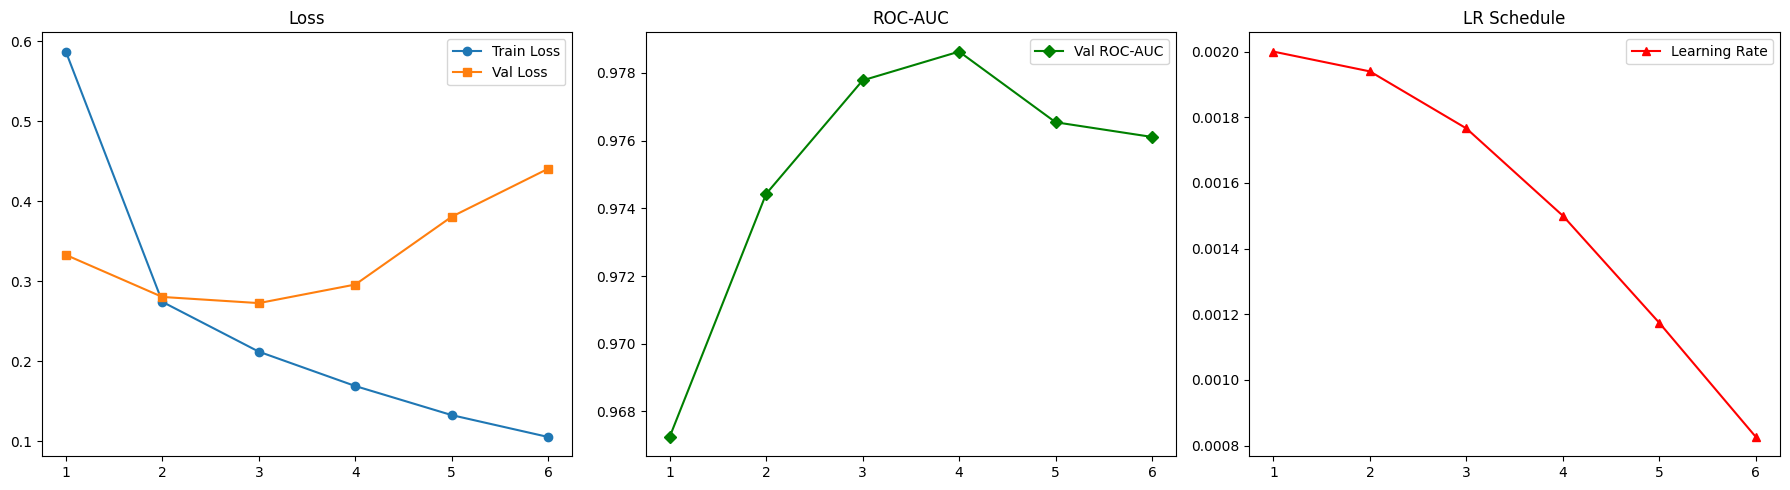


############################################################
# Training model: bilstm
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building bilstm model...
Trainable parameters: 6,277,382

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for bilstm...


Epoch 1/10: 100%|██████████| 1995/1995 [09:07<00:00,  3.65it/s, loss=0.2575]



Epoch 1 Summary:
  Train Loss: 0.5552 | Val Loss: 0.3231 | Val ROC-AUC: 0.9695


Epoch 2/10: 100%|██████████| 1995/1995 [09:05<00:00,  3.66it/s, loss=0.1521]



Epoch 2 Summary:
  Train Loss: 0.2704 | Val Loss: 0.2704 | Val ROC-AUC: 0.9769
  ✅ EarlyStopping: metric improved


...


Epoch 4 Summary:
  Train Loss: 0.1579 | Val Loss: 0.3019 | Val ROC-AUC: 0.9800
  ✅ EarlyStopping: metric improved


Epoch 5/10: 100%|██████████| 1995/1995 [09:07<00:00,  3.64it/s, loss=0.0894]



Epoch 5 Summary:
  Train Loss: 0.1208 | Val Loss: 0.3602 | Val ROC-AUC: 0.9799
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 6/10: 100%|██████████| 1995/1995 [09:05<00:00,  3.66it/s, loss=0.1043]



Epoch 6 Summary:
  Train Loss: 0.0915 | Val Loss: 0.4893 | Val ROC-AUC: 0.9776
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 6!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.89 0.89 0.89 0.89 0.89 0.89]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.60      0.89      0.71      3046
 severe_toxic       0.21      0.97      0.35       305
      obscene       0.58      0.94      0.72      1662
       threat       0.13      0.73      0.22        98
       insult       0.48      0.93      0.63      1576
identity_hate       0.14      0.84      0.23       259

    micro avg       0.46      0.91      0.61      6946
    macro avg       0.36      0.88      0.48      6946
 weighted avg       0.53      0.91      0.66      6946
  samples avg       0.05      0.09      0.06      6946


Per-Class ROC-AUC:
  toxic               : 

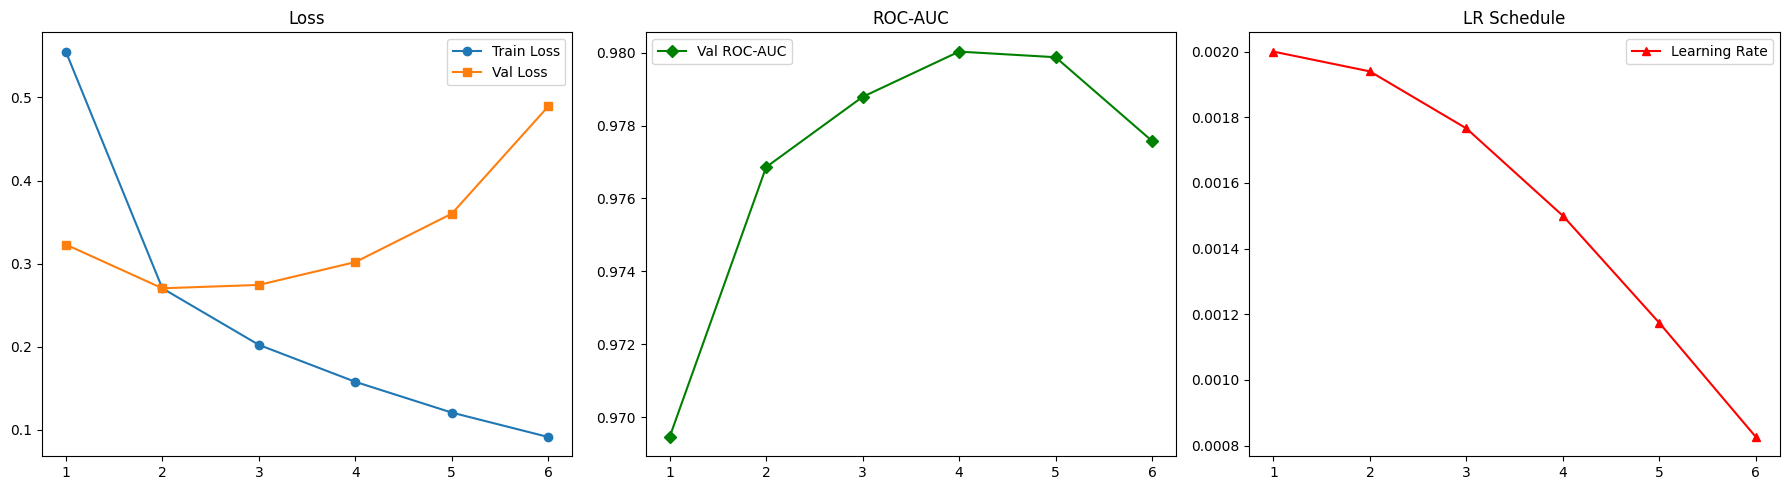


############################################################
# Training model: attention_bilstm
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building attention_bilstm model...
Trainable parameters: 6,540,550

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for attention_bilstm...


Epoch 1/10: 100%|██████████| 1995/1995 [09:12<00:00,  3.61it/s, loss=1.7143]



Epoch 1 Summary:
  Train Loss: 0.4864 | Val Loss: 0.3826 | Val ROC-AUC: 0.9729


Epoch 2/10: 100%|██████████| 1995/1995 [09:10<00:00,  3.62it/s, loss=0.0577]



Epoch 2 Summary:
  Train Loss: 0.2474 | Val Loss: 0.2558 | Val ROC-AUC: 0.9824
  ✅ EarlyStopping: metric improved


...


Epoch 5 Summary:
  Train Loss: 0.1016 | Val Loss: 0.3902 | Val ROC-AUC: 0.9834
  ✅ EarlyStopping: metric improved


Epoch 6/10: 100%|██████████| 1995/1995 [09:09<00:00,  3.63it/s, loss=0.1430]



Epoch 6 Summary:
  Train Loss: 0.0770 | Val Loss: 0.4813 | Val ROC-AUC: 0.9827
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 7/10: 100%|██████████| 1995/1995 [09:08<00:00,  3.64it/s, loss=0.1452]



Epoch 7 Summary:
  Train Loss: 0.0579 | Val Loss: 0.6604 | Val ROC-AUC: 0.9830
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 7!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.88 0.88 0.89 0.84 0.89 0.87]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.67      0.87      0.76      3046
 severe_toxic       0.29      0.91      0.44       305
      obscene       0.62      0.94      0.75      1662
       threat       0.37      0.68      0.48        98
       insult       0.54      0.92      0.68      1576
identity_hate       0.32      0.73      0.45       259

    micro avg       0.57      0.89      0.70      6946
    macro avg       0.47      0.84      0.59      6946
 weighted avg       0.60      0.89      0.71      6946
  samples avg       0.06      0.08      0.07      6946


Per-Class ROC-AUC:
  toxic               : 

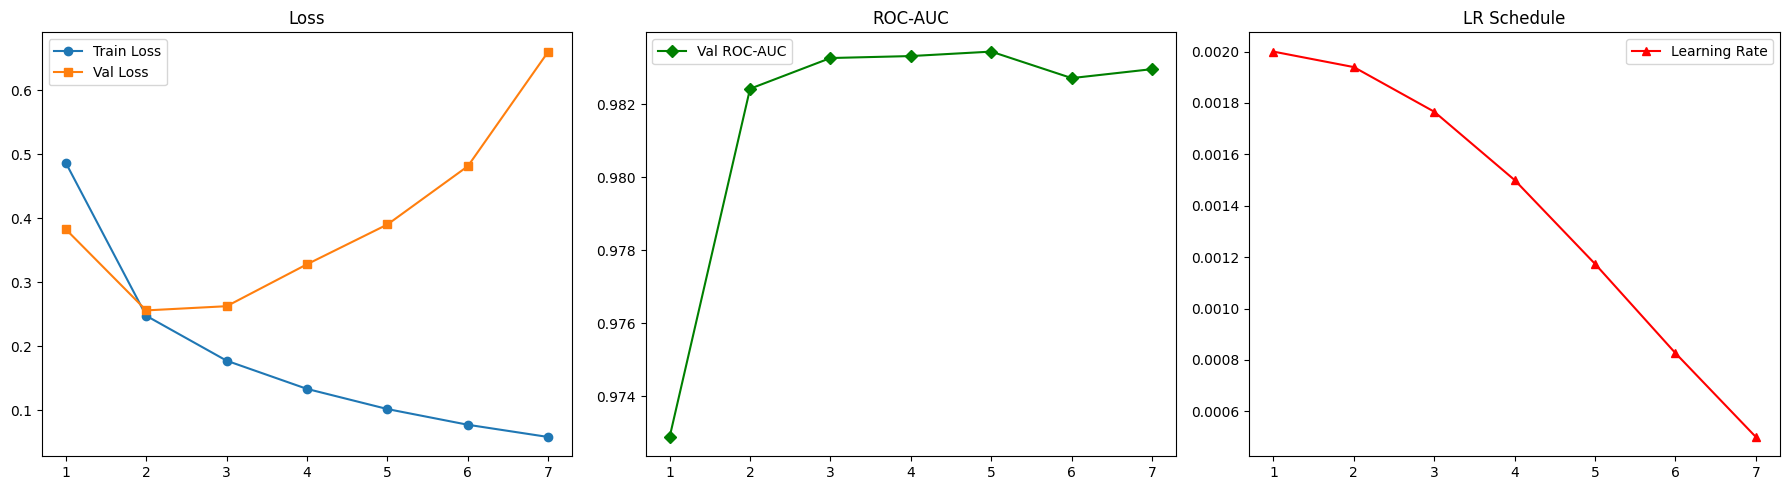


############################################################
# Training model: attention_lstm
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building attention_lstm model...
Trainable parameters: 4,896,006

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for attention_lstm...


Epoch 1/10: 100%|██████████| 1995/1995 [05:24<00:00,  6.14it/s, loss=0.3135]



Epoch 1 Summary:
  Train Loss: 0.4989 | Val Loss: 0.3722 | Val ROC-AUC: 0.9691


Epoch 2/10: 100%|██████████| 1995/1995 [05:25<00:00,  6.13it/s, loss=0.1485]



Epoch 2 Summary:
  Train Loss: 0.2586 | Val Loss: 0.2573 | Val ROC-AUC: 0.9805
  ✅ EarlyStopping: metric improved


...


Epoch 3 Summary:
  Train Loss: 0.1887 | Val Loss: 0.2513 | Val ROC-AUC: 0.9812
  ✅ EarlyStopping: metric improved


Epoch 4/10: 100%|██████████| 1995/1995 [05:21<00:00,  6.20it/s, loss=0.1449]



Epoch 4 Summary:
  Train Loss: 0.1448 | Val Loss: 0.3111 | Val ROC-AUC: 0.9787
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 5/10: 100%|██████████| 1995/1995 [05:21<00:00,  6.21it/s, loss=0.0279]



Epoch 5 Summary:
  Train Loss: 0.1103 | Val Loss: 0.3893 | Val ROC-AUC: 0.9791
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 5!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.89 0.89 0.89 0.89 0.89 0.89]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.52      0.92      0.66      3046
 severe_toxic       0.21      0.96      0.35       305
      obscene       0.49      0.96      0.65      1662
       threat       0.14      0.77      0.24        98
       insult       0.39      0.96      0.55      1576
identity_hate       0.12      0.91      0.21       259

    micro avg       0.40      0.94      0.56      6946
    macro avg       0.31      0.91      0.45      6946
 weighted avg       0.45      0.94      0.60      6946
  samples avg       0.05      0.09      0.06      6946


Per-Class ROC-AUC:
  toxic               : 

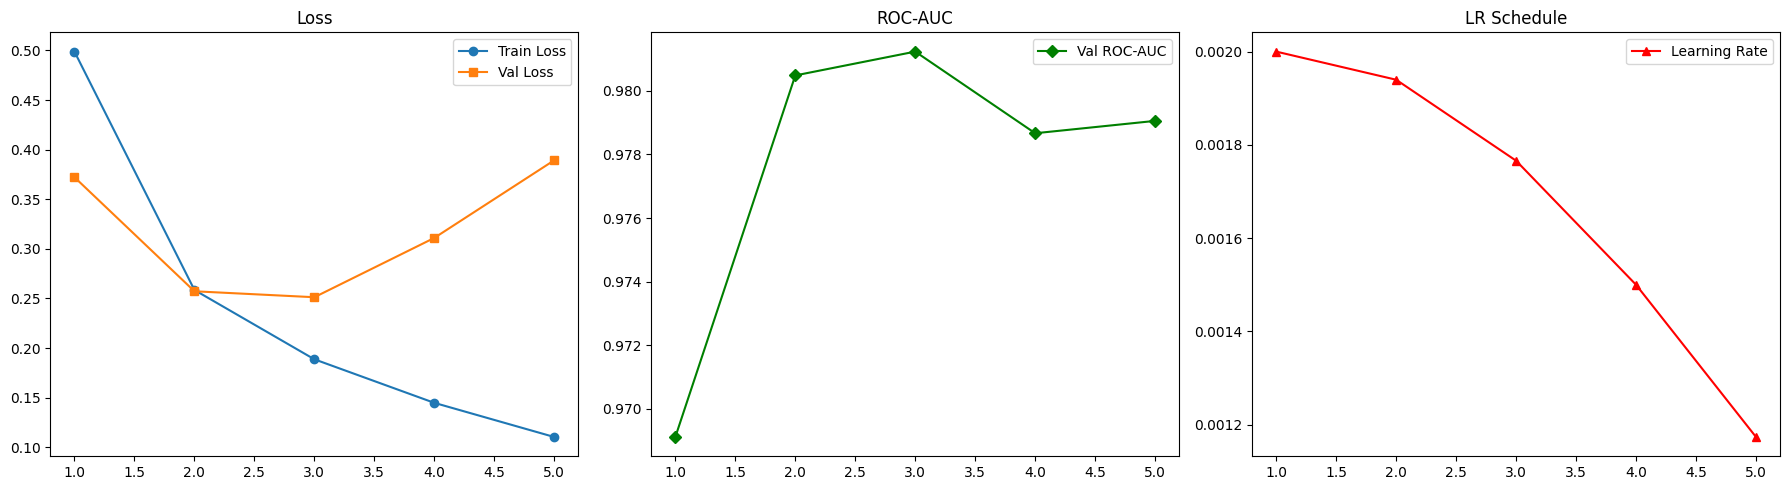


############################################################
# Training model: gru
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building gru model...
Trainable parameters: 4,599,558

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for gru...


Epoch 1/10: 100%|██████████| 1995/1995 [06:51<00:00,  4.84it/s, loss=1.3102]



Epoch 1 Summary:
  Train Loss: 0.4914 | Val Loss: 0.3106 | Val ROC-AUC: 0.9738


Epoch 2/10: 100%|██████████| 1995/1995 [06:44<00:00,  4.93it/s, loss=0.8155]



Epoch 2 Summary:
  Train Loss: 0.2571 | Val Loss: 0.2740 | Val ROC-AUC: 0.9805
  ✅ EarlyStopping: metric improved


Epoch 3/10: 100%|██████████| 1995/1995 [06:34<00:00,  5.06it/s, loss=0.3429]



Epoch 3 Summary:
  Train Loss: 0.1890 | Val Loss: 0.2847 | Val ROC-AUC: 0.9794
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 4/10: 100%|██████████| 1995/1995 [06:53<00:00,  4.82it/s, loss=0.4550]



Epoch 4 Summary:
  Train Loss: 0.1486 | Val Loss: 0.3045 | Val ROC-AUC: 0.9793
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 4!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.88 0.89 0.89 0.89 0.89 0.89]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.55      0.90      0.68      3046
 severe_toxic       0.15      0.98      0.27       305
      obscene       0.46      0.96      0.62      1662
       threat       0.11      0.78      0.19        98
       insult       0.38      0.96      0.55      1576
identity_hate       0.11      0.88      0.19       259

    micro avg       0.38      0.93      0.53      6946
    macro avg       0.29      0.91      0.42      6946
 weighted avg       0.45      0.93      0.59      6946
  samples avg       0.05      0.09      0.06      6946


Per-Class ROC-AUC:
  toxic               : 

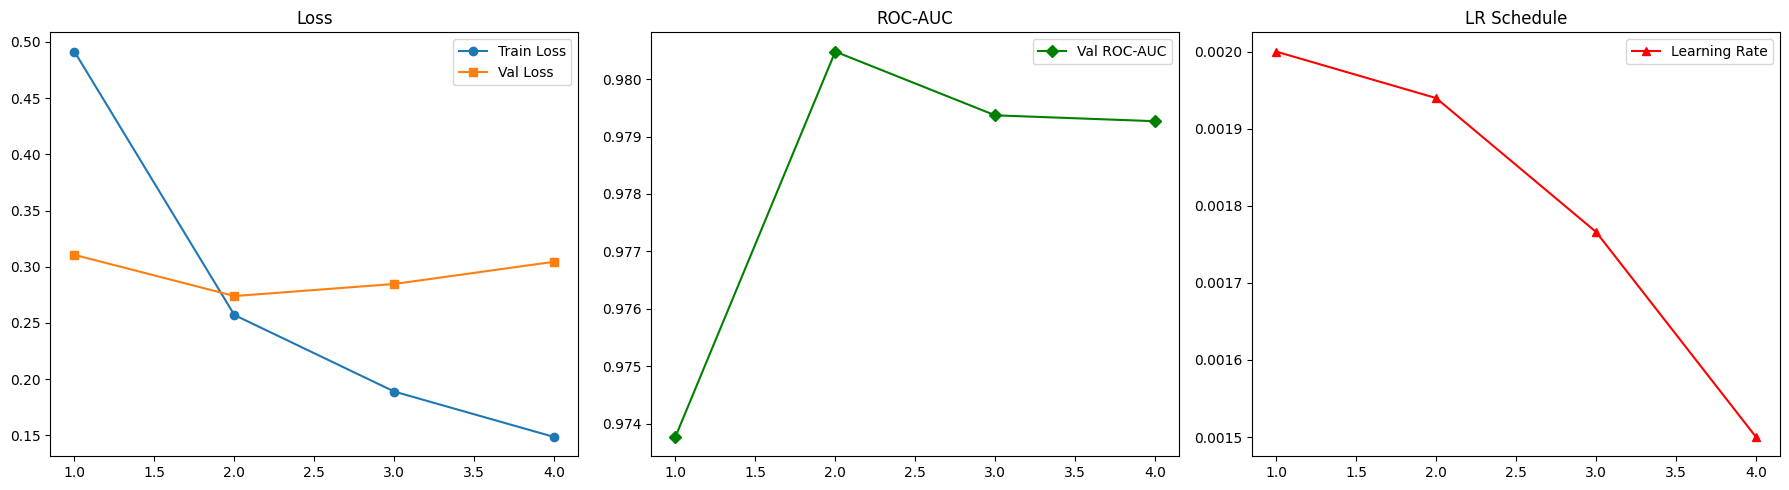


############################################################
# Training model: rcnn
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building rcnn model...
Trainable parameters: 6,605,574

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for rcnn...


Epoch 1/10: 100%|██████████| 1995/1995 [08:59<00:00,  3.70it/s, loss=1.4706]



Epoch 1 Summary:
  Train Loss: 0.4790 | Val Loss: 0.3068 | Val ROC-AUC: 0.9770


Epoch 2/10: 100%|██████████| 1995/1995 [08:46<00:00,  3.79it/s, loss=0.5797]



Epoch 2 Summary:
  Train Loss: 0.2607 | Val Loss: 0.2748 | Val ROC-AUC: 0.9831
  ✅ EarlyStopping: metric improved


...


Epoch 3 Summary:
  Train Loss: 0.1976 | Val Loss: 0.2986 | Val ROC-AUC: 0.9839
  ✅ EarlyStopping: metric improved


Epoch 4/10: 100%|██████████| 1995/1995 [08:54<00:00,  3.74it/s, loss=0.2682]



Epoch 4 Summary:
  Train Loss: 0.1527 | Val Loss: 0.3177 | Val ROC-AUC: 0.9835
  ⏳ EarlyStopping: 1/2 (no improvement)


Epoch 5/10: 100%|██████████| 1995/1995 [08:55<00:00,  3.73it/s, loss=0.0723]



Epoch 5 Summary:
  Train Loss: 0.1215 | Val Loss: 0.3556 | Val ROC-AUC: 0.9831
  ⏳ EarlyStopping: 2/2 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 5!

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.86 0.89 0.62 0.83 0.85 0.89]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.62      0.89      0.73      3046
 severe_toxic       0.25      0.96      0.40       305
      obscene       0.76      0.87      0.81      1662
       threat       0.29      0.79      0.43        98
       insult       0.55      0.92      0.69      1576
identity_hate       0.20      0.85      0.32       259

    micro avg       0.54      0.89      0.67      6946
    macro avg       0.44      0.88      0.56      6946
 weighted avg       0.60      0.89      0.70      6946
  samples avg       0.06      0.09      0.07      6946


Per-Class ROC-AUC:
  toxic               : 

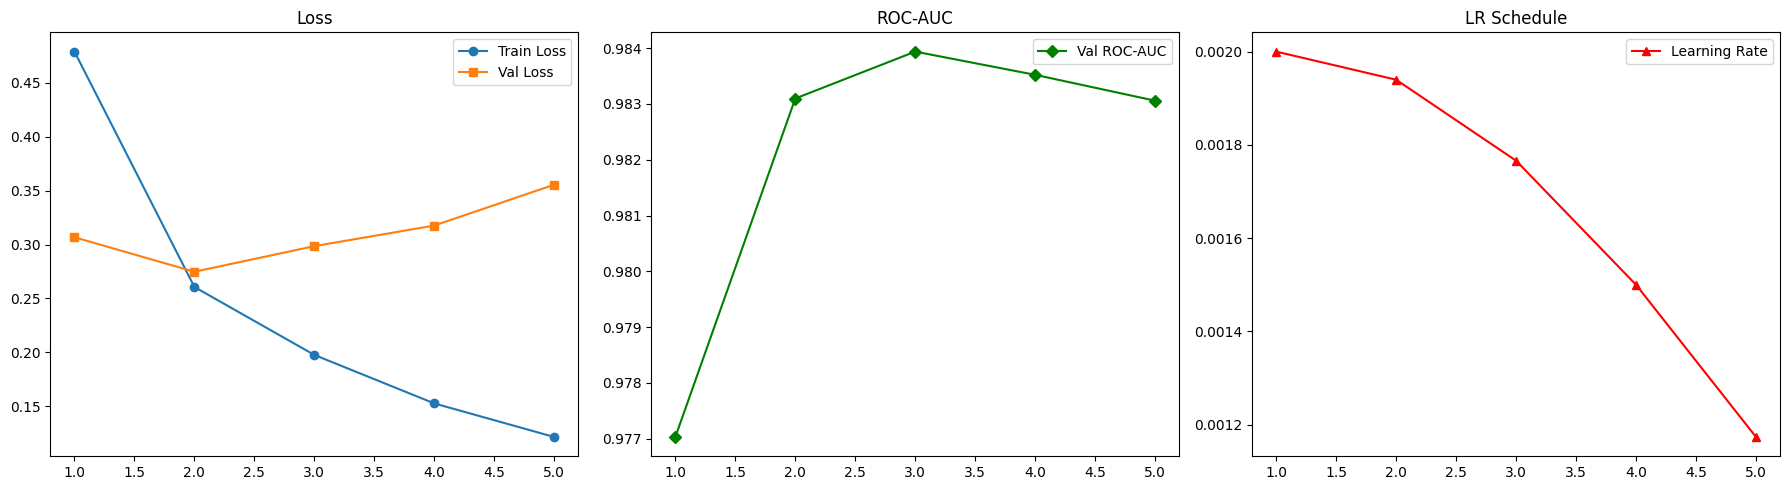


############################################################
# Training model: transformer
############################################################
Using device: cuda
Loading data...
Initializing tokenizers...
Building transformer model...
Trainable parameters: 4,304,134

Class weights applied to handle highly imbalanced data:
  toxic               : 9.43
  severe_toxic        : 50.00
  obscene             : 17.89
  threat              : 50.00
  insult              : 19.26
  identity_hate       : 50.00

Starting training for transformer...


Epoch 1/10: 100%|██████████| 1995/1995 [01:43<00:00, 19.25it/s, loss=0.5916]



Epoch 1 Summary:
  Train Loss: 0.5710 | Val Loss: 0.4264 | Val ROC-AUC: 0.9587


Epoch 2/10: 100%|██████████| 1995/1995 [01:43<00:00, 19.30it/s, loss=0.1923]



Epoch 2 Summary:
  Train Loss: 0.3828 | Val Loss: 0.4191 | Val ROC-AUC: 0.9618
  ✅ EarlyStopping: metric improved


...


Epoch 8 Summary:
  Train Loss: 0.2378 | Val Loss: 0.3129 | Val ROC-AUC: 0.9782
  ✅ EarlyStopping: metric improved


Epoch 9/10: 100%|██████████| 1995/1995 [01:44<00:00, 19.12it/s, loss=0.2062]



Epoch 9 Summary:
  Train Loss: 0.2293 | Val Loss: 0.3071 | Val ROC-AUC: 0.9789
  ✅ EarlyStopping: metric improved


Epoch 10/10: 100%|██████████| 1995/1995 [01:44<00:00, 19.16it/s, loss=0.1622]



Epoch 10 Summary:
  Train Loss: 0.2253 | Val Loss: 0.3135 | Val ROC-AUC: 0.9788
  ⏳ EarlyStopping: 1/2 (no improvement)

FINAL EVALUATION ON VALIDATION SET (Best Model)

Optimal per-class thresholds: [0.86 0.89 0.89 0.89 0.89 0.89]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.63      0.86      0.72      3046
 severe_toxic       0.20      0.96      0.33       305
      obscene       0.55      0.94      0.70      1662
       threat       0.10      0.70      0.18        98
       insult       0.44      0.93      0.60      1576
identity_hate       0.14      0.84      0.24       259

    micro avg       0.45      0.90      0.59      6946
    macro avg       0.34      0.87      0.46      6946
 weighted avg       0.52      0.90      0.65      6946
  samples avg       0.05      0.08      0.06      6946


Per-Class ROC-AUC:
  toxic               : 0.9684
  severe_toxic        : 0.9864
  obscene             : 0.9871
  threat              :

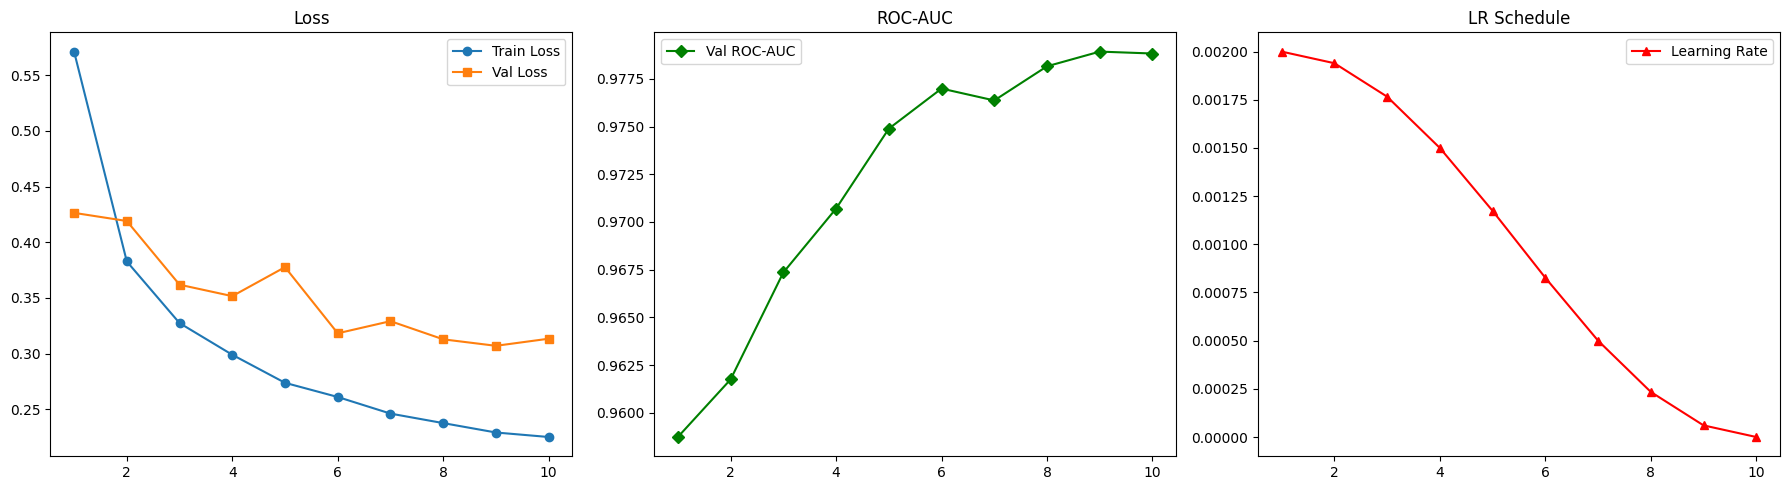


MODEL COMPARISON RESULTS
Model                  Best Val AUC    Final AUC    F1 Macro     F1 Micro    
----------------------------------------------------------------------
lstm                   0.9786          0.9761       0.5459       0.6658      
bilstm                 0.9800          0.9776       0.5520       0.6689      
attention_bilstm       0.9834          0.9830       0.6311       0.7324      
attention_lstm         0.9812          0.9791       0.5650       0.6820      
gru                    0.9805          0.9793       0.5146       0.6198      
rcnn                   0.9839          0.9831       0.5689       0.6655      
transformer            0.9789          0.9788       0.4625       0.5947      

 BEST MODEL: rcnn (Val ROC-AUC = 0.9839)
Generating submission with best model...

Generating submission to submission.csv...


Submission file saved as 'submission.csv'.


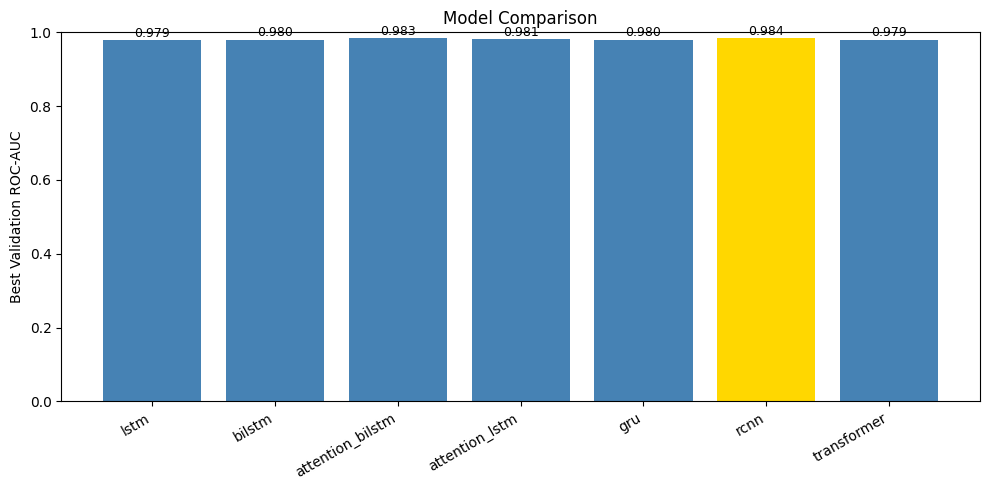


Submission saved to 'submission.csv'
Done!


In [9]:
def run_all_models(sample_size=None):
    """Train all models, evaluate them, and pick the best one for submission."""
    ALL_MODELS = [
        LSTM_MODEL,
        BILSTM_MODEL,
        ATTENTION_BILSTM_MODEL,
        'attention_lstm',
        GRU_MODEL,
        RCNN_MODEL,
        TRANSFORMER_MODEL,
    ]

    results = {}
    for model_type in ALL_MODELS:
        print("\n" + "#" * 60)
        print(f"# Training model: {model_type}")
        print("#" * 60)
        try:
            result = main(model_type=model_type, sample_size=sample_size)
            results[model_type] = result
        except Exception as e:
            print(f"  ERROR training {model_type}: {e}")
            results[model_type] = None

    # ========== Comparison Table ==========
    print("\n" + "=" * 70)
    print("MODEL COMPARISON RESULTS")
    print("=" * 70)
    header = f"{'Model':<22} {'Best Val AUC':<15} {'Final AUC':<12} {'F1 Macro':<12} {'F1 Micro':<12}"
    print(header)
    print("-" * 70)

    best_model_type = None
    best_auc = -1.0

    for model_type, res in results.items():
        if res is None:
            print(f"{model_type:<22} FAILED")
            continue
        auc = res['best_val_auc']
        print(f"{model_type:<22} {auc:<15.4f} {res['final_val_auc']:<12.4f} {res['final_f1_macro']:<12.4f} {res['final_f1_micro']:<12.4f}")
        if auc > best_auc:
            best_auc = auc
            best_model_type = model_type

    print("=" * 70)

    if best_model_type is None:
        print("No model trained successfully.")
        return

    print(f"\n BEST MODEL: {best_model_type} (Val ROC-AUC = {best_auc:.4f})")
    print(f"Generating submission with best model...\n")

    best = results[best_model_type]
    generate_submission(best['model'], best['processor'], best['device'], SUBMISSION_CSV_PATH)

    # ========== Summary plot ==========
    model_names = []
    aucs = []
    for m, res in results.items():
        if res is not None:
            model_names.append(m)
            aucs.append(res['best_val_auc'])

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(model_names, aucs, color=['gold' if m == best_model_type else 'steelblue' for m in model_names])
    ax.set_ylabel('Best Validation ROC-AUC')
    ax.set_title('Model Comparison')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nSubmission saved to '{SUBMISSION_CSV_PATH}'")
    print("Done!")


# ==========================================
# Run ALL models and pick the best for submission
# Set sample_size=10000 for quick testing, or None for full dataset
# ==========================================
run_all_models(sample_size=None)
